## Activity: Build a Naive Bayes model

For this activity, The league is interested in retaining players who can last in the high-pressure environment of professional basketball and help the team be successful over time. In the previous activity, you analyzed a subset of data that contained information about the NBA players and their performance records. You conducted feature engineering to determine which features would most effectively predict a player's career duration. You will now use those insights to build a model that predicts whether a player will have an NBA career lasting five years or more.

The data for this activity consists of performance statistics from each player's rookie year. There are 1,341 observations, and each observation in the data represents a different player in the NBA. Your target variable is a Boolean value that indicates whether a given player will last in the league for five years. Since you previously performed feature engineering on this data, it is now ready for modeling

In [1]:
# Import modules & libraries

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB


from sklearn.metrics import f1_score, recall_score, accuracy_score, precision_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [14]:
# import the data

nba_feat = pd.read_csv('./raw_data/nba-players-featured-eng.csv')
nba_raw = pd.read_csv('./raw_data/nba-players.csv')
nba_feat.drop(['Unnamed: 0'],axis=1,inplace=True)
nba_feat.head()

,gp,min,pts,3pa,3p_made,target_5yrs,TotalPoints,3p_TotalAtmp,3p_TotalPts,PointEff
0,36,27.4,7.4,2.1,0.5,0,266.4,75.6,54.0,27.007
1,35,26.9,7.2,2.8,0.7,0,252.0,98.0,73.5,26.766
2,74,15.3,5.2,1.7,0.4,0,384.8,125.8,88.8,33.987
3,58,11.6,5.7,0.5,0.1,1,330.6,29.0,17.4,49.138
4,48,11.5,4.5,0.1,0.0,1,216.0,4.8,0.0,39.130


In [20]:
#nba_raw.drop('Unnamed: 0',axis=1,inplace=True)
print(nba_raw.columns)
nba_raw.head()

#Feature selection
nba_extra_stats = nba_raw[['reb', 'ast', 'stl', 'blk']]
nba_extra_stats.head()

nba_enreached = nba_feat.join(nba_extra_stats,)
nba_enreached

Index(['name', 'gp', 'min', 'pts', 'fgm', 'fga', 'fg', '3p_made', '3pa', '3p',
       'ftm', 'fta', 'ft', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov',
       'target_5yrs'],
      dtype='object')


,gp,min,pts,3pa,3p_made,target_5yrs,TotalPoints,3p_TotalAtmp,3p_TotalPts,PointEff,reb,ast,stl,blk
0,36,27.4,7.4,2.1,0.5,0,266.4,75.6,54.0,27.007,4.1,1.9,0.4,0.4
1,35,26.9,7.2,2.8,0.7,0,252.0,98.0,73.5,26.766,2.4,3.7,1.1,0.5
2,74,15.3,5.2,1.7,0.4,0,384.8,125.8,88.8,33.987,2.2,1.0,0.5,0.3
3,58,11.6,5.7,0.5,0.1,1,330.6,29.0,17.4,49.138,1.9,0.8,0.6,0.1
4,48,11.5,4.5,0.1,0.0,1,216.0,4.8,0.0,39.130,2.5,0.3,0.3,0.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,80,15.8,4.3,0.2,0.0,0,344.0,16.0,0.0,27.215,1.2,2.5,0.6,0.2
1336,68,12.6,3.9,0.7,0.1,1,265.2,47.6,20.4,30.952,1.5,2.3,0.8,0.0
1337,43,12.1,5.4,0.0,0.0,0,232.2,0.0,0.0,44.628,3.8,0.3,0.3,0.4
1338,52,12.0,4.5,0.2,0.0,1,234.0,10.4,0.0,37.500,0.7,2.2,0.4,0.1


In [21]:
y = nba_enreached['target_5yrs']
nba_enreached['PointEff'] = nba_enreached['PointEff']/100
x = nba_enreached[['gp','min','pts','3pa','TotalPoints','PointEff','reb', 'ast', 'stl', 'blk']]

x_train, x_test, y_train, y_test = train_test_split(x,y,random_state=42,test_size=0.2,stratify=y)

In [22]:
x_train.describe()

,gp,min,pts,3pa,TotalPoints,PointEff,reb,ast,stl,blk
count,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000,1072.000000
mean,60.417910,17.606530,6.835354,0.761660,455.318097,0.372732,3.033955,1.573228,0.620709,0.367910
std,17.566541,8.425369,4.443200,1.053939,374.778690,0.093064,2.092721,1.511661,0.418771,0.439034
min,11.000000,3.100000,0.700000,0.000000,14.700000,0.121950,0.300000,0.000000,0.000000,0.000000
25%,47.000000,10.675000,3.700000,0.000000,174.000000,0.310505,1.500000,0.600000,0.300000,0.100000
50%,63.000000,15.950000,5.500000,0.300000,336.000000,0.364390,2.500000,1.100000,0.500000,0.200000
75%,77.000000,23.000000,8.800000,1.100000,647.050000,0.431508,3.900000,2.000000,0.800000,0.500000
max,82.000000,40.900000,28.200000,6.500000,2312.400000,0.738460,13.900000,10.600000,2.500000,3.900000


In [23]:
x_test.describe()

,gp,min,pts,3pa,TotalPoints,PointEff,reb,ast,stl,blk
count,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000,268.000000
mean,60.399254,17.697015,6.666045,0.849254,437.644403,0.364462,3.036567,1.459701,0.609701,0.371269
std,16.925512,7.835418,4.001564,1.092106,331.710948,0.095892,1.915325,1.295230,0.372132,0.387292
min,15.000000,4.200000,1.000000,0.000000,18.000000,0.126580,0.500000,0.100000,0.000000,0.000000
25%,47.750000,11.300000,3.600000,0.000000,168.175000,0.295375,1.500000,0.600000,0.300000,0.100000
50%,63.000000,16.950000,5.750000,0.400000,344.100000,0.360510,2.700000,1.100000,0.500000,0.200000
75%,76.000000,22.625000,8.525000,1.300000,595.700000,0.428222,4.125000,1.800000,0.800000,0.500000
max,82.000000,38.600000,21.600000,6.100000,1771.200000,0.690480,11.000000,7.700000,2.000000,1.800000


In [24]:
# Data normalization

minMaxScaler = MinMaxScaler()

x_train_n = minMaxScaler.fit_transform(x_train)
x_test_n = minMaxScaler.transform(x_test)

In [25]:
# Model building

nba_gaussianNB = GaussianNB().fit(x_train_n,y_train)
nba_gNB_prediction = nba_gaussianNB.predict(x_test_n)

#Check the metrics
print(f'accuracy_score: {accuracy_score(y_test,nba_gNB_prediction):.4f}')
print(f'precision_score: {precision_score(y_test,nba_gNB_prediction):.4f}')
print(f'recall_score: {recall_score(y_test,nba_gNB_prediction):.4f}')
print(f'f1_score: {f1_score(y_test,nba_gNB_prediction):.4f}')

accuracy_score: 0.6455
precision_score: 0.7934
recall_score: 0.5783
f1_score: 0.6690


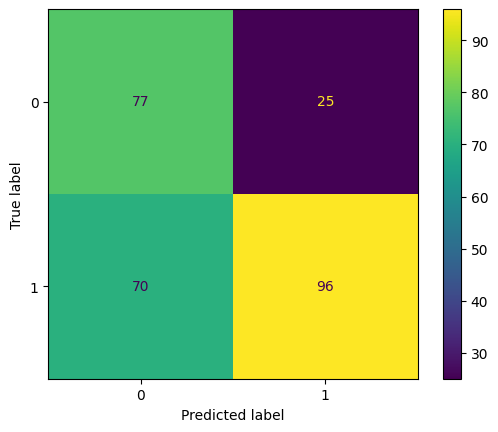

In [27]:
#Build the confusion matrix

confMatrix = confusion_matrix(y_test,nba_gNB_prediction,labels=nba_gaussianNB.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=confMatrix,display_labels=nba_gaussianNB.classes_)
disp.plot()